# Линейные модели
Контрольная проверка Ridge, ElasticNet и Huber на двух таргетах и трёх шкалах таргета. Бейзлайн это предсказание медианой train.

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

datapath = "/kaggle/input/datasets/vikakolganova/crmses/sessions_crm.parquet"
seed = 42
maxrows = 90000
np.random.seed(seed)

data = pd.read_parquet(datapath)
for c in ["start", "end", "install_datetime", "prev_session_end", "session_date"]:
    if c in data.columns:
        data[c] = pd.to_datetime(data[c], errors="coerce")
print(data.shape)

(3071996, 85)


## Подготовка
Сплит 70/15/15 по времени, из признаков убираю идентификаторы, временные колонки и колонки таргетов.

In [2]:
targets = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d"]
labels = {"target_next_session_length_sec": "next_session", "future_sessions_mean_playtime_7d": "crm_7d"}

from types import SimpleNamespace

blacklist = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d", "target_log1p",
             "appmetrica_device_id", "installation_id", "session_id",
             "start", "end", "duration_hms", "session_date", "install_datetime", "prev_session_end"]

def prepare(data, target):
    d = data.sort_values("start").reset_index(drop=True)
    if len(d) > maxrows:
        d = d.tail(maxrows).reset_index(drop=True)
    feats = [c for c in d.columns if c not in blacklist and not c.startswith("target") and not c.startswith("future_")]
    catcols = [c for c in feats if not pd.api.types.is_numeric_dtype(d[c])]
    for c in feats:
        if c in catcols:
            d[c] = d[c].astype(str).fillna("unknown")
        else:
            d[c] = d[c].fillna(d[c].median())
    n = len(d)
    i = int(n * 0.70)
    j = int(n * 0.85)
    x = d[feats]
    y = d[target].values.astype(float)
    pack = SimpleNamespace(xtrain=x.iloc[:i].reset_index(drop=True),
                           xval=x.iloc[i:j].reset_index(drop=True),
                           xtest=x.iloc[j:].reset_index(drop=True),
                           ytrain=y[:i], yval=y[i:j], ytest=y[j:],
                           catcols=catcols, target=target)
    for c in catcols:
        pack.xtrain[c] = pack.xtrain[c].astype(str)
        pack.xval[c] = pack.xval[c].astype(str)
        pack.xtest[c] = pack.xtest[c].astype(str)
    return pack

packs = {t: prepare(data, t) for t in targets}
print(packs[targets[0]].xtrain.shape, packs[targets[0]].catcols)

(62999, 73) ['publisher_name', 'tracker_name', 'attributed_touch_type', 'country_iso_code', 'device_type', 'app_version_name', 'connection_type', 'traffic_source', 'install_country', 'install_device_type', 'install_app_version_name', 'install_connection_type', 'most_common_event_name', 'most_common_connection_type']


## Метрики

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prodmae(yt, yp, cap=1200, tail=0.2, over=2.0, under=1.0):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    a = np.minimum(yt, cap)
    b = np.minimum(yp, cap)
    err = b - a
    w = np.where(yt > cap, tail, 1.0) * np.where(err > 0, over, under)
    return np.sum(w * np.abs(err)) / np.sum(w)

def engmae(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    ae = np.abs(yt - yp)
    w = np.select([yt <= 300, (yt > 300) & (yt <= 1200), yt > 1200], [1.0, 0.67, 0.05])
    return np.sum(w * ae) / np.sum(w)

def segmae(yt, yp, lo, hi):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    m = (yt > lo) & (yt <= hi)
    if m.any():
        return float(np.mean(np.abs(yt[m] - yp[m])))
    return np.nan

def score(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.clip(np.asarray(yp, float), 0, None)
    ae = np.abs(yt - yp)
    return {"mae": mean_absolute_error(yt, yp),
            "rmse": mean_squared_error(yt, yp) ** 0.5,
            "medae": float(np.median(ae)),
            "r2": r2_score(yt, yp),
            "p70_abs_error": float(np.percentile(ae, 70)),
            "p90_abs_error": float(np.percentile(ae, 90)),
            "product_mae": prodmae(yt, yp),
            "engagement_risk_mae": engmae(yt, yp),
            "small_mae": segmae(yt, yp, -1, 300),
            "normal_mae": segmae(yt, yp, 300, 1200),
            "long_mae": segmae(yt, yp, 1200, 1e18)}

rows = []
preds = {}

def record(target, family, name, mode, loss, yval, valpred, ytest=None, testpred=None,
           params="", btmean=np.nan, btstd=np.nan, fitsec=0.0):
    row = {"target": target, "target_label": labels.get(target, target), "model_family": family,
           "model_name": name, "objective_tag": loss, "target_mode": mode, "loss_function": loss,
           "feature_set": "all", "params": params, "fit_sec": round(fitsec, 1), "status": "ok"}
    mv = score(yval, valpred)
    for k, v in mv.items():
        row["val_" + k] = v
    if testpred is not None:
        for k, v in score(ytest, testpred).items():
            row["test_" + k] = v
        preds[(target, name)] = (np.asarray(ytest, float), np.clip(np.asarray(testpred, float), 0, None))
    row["backtest_mae_mean"] = btmean
    row["backtest_mae_std"] = btstd
    rows.append(row)
    msg = labels.get(target, target) + "  " + name + "  val_mae=" + str(round(mv["mae"], 1)) + "  r2=" + str(round(mv["r2"], 2))
    if testpred is not None:
        msg += "  test_mae=" + str(round(row["test_mae"], 1))
    print(msg)

In [4]:
def makescale(ytrain, mode):
    cap = np.percentile(np.asarray(ytrain, float), 99.5)
    if mode == "raw":
        return (lambda s: np.asarray(s, float)), (lambda s: np.asarray(s, float))
    if mode == "p995":
        return (lambda s: np.clip(np.asarray(s, float), 0, cap)), (lambda s: np.asarray(s, float))
    return (lambda s: np.log1p(np.clip(np.asarray(s, float), 0, cap))), (lambda s: np.expm1(np.asarray(s, float)))

## Обучение

In [5]:
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler

for t in targets:
    pack = packs[t]
    ncols = [c for c in pack.xtrain.columns if c not in pack.catcols]
    sc = StandardScaler().fit(pack.xtrain[ncols])
    xtr = sc.transform(pack.xtrain[ncols])
    xvl = sc.transform(pack.xval[ncols])
    xte = sc.transform(pack.xtest[ncols])
    dm = DummyRegressor(strategy="median").fit(xtr, pack.ytrain)
    record(t, "baseline", "dummy_median", "raw", "median", pack.yval, dm.predict(xvl), pack.ytest, dm.predict(xte))
    for mode in ["raw", "p995", "log1p_p995"]:
        fwd, inv = makescale(pack.ytrain, mode)
        ytr = fwd(pack.ytrain)
        models = {"ridge": Ridge(alpha=1.0, random_state=seed),
                  "elasticnet": ElasticNet(alpha=0.01, l1_ratio=0.8, random_state=seed),
                  "huber": HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=300)}
        for name, model in models.items():
            t0 = time.time()
            model.fit(xtr, ytr)
            record(t, "linear", name + "_" + mode, mode, name, pack.yval,
                   inv(model.predict(xvl)), pack.ytest, inv(model.predict(xte)), fitsec=time.time() - t0)

next_session  dummy_median  val_mae=596.0  r2=-0.06  test_mae=639.7
next_session  ridge_raw  val_mae=651.7  r2=0.08  test_mae=699.1
next_session  elasticnet_raw  val_mae=651.7  r2=0.08  test_mae=699.1
next_session  huber_raw  val_mae=571.7  r2=0.02  test_mae=618.8
next_session  ridge_p995  val_mae=630.8  r2=0.06  test_mae=678.9
next_session  elasticnet_p995  val_mae=630.8  r2=0.06  test_mae=678.9
next_session  huber_p995  val_mae=571.7  r2=0.02  test_mae=618.8
next_session  ridge_log1p_p995  val_mae=583.5  r2=-0.1  test_mae=625.2
next_session  elasticnet_log1p_p995  val_mae=583.1  r2=-0.08  test_mae=626.1
next_session  huber_log1p_p995  val_mae=611.3  r2=-2.71  test_mae=639.0
crm_7d  dummy_median  val_mae=357.3  r2=-0.07  test_mae=349.7
crm_7d  ridge_raw  val_mae=325.4  r2=0.21  test_mae=327.8
crm_7d  elasticnet_raw  val_mae=325.6  r2=0.21  test_mae=327.8
crm_7d  huber_raw  val_mae=308.1  r2=0.17  test_mae=304.3
crm_7d  ridge_p995  val_mae=324.0  r2=0.21  test_mae=325.7
crm_7d  elastic

## Сравнение

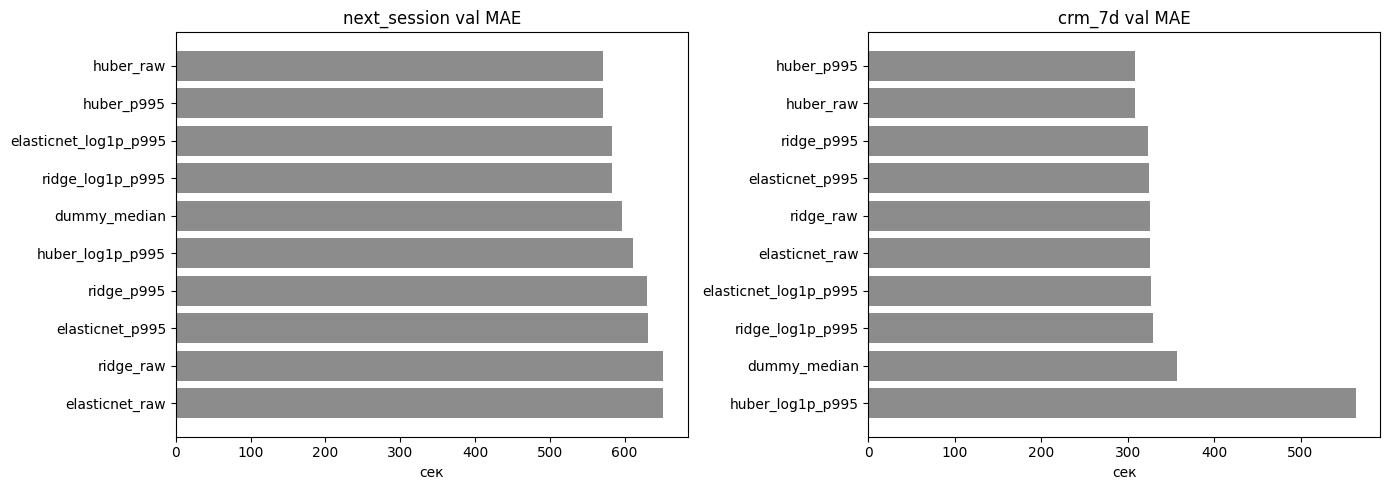

In [6]:
res = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t in zip(axes, targets):
    sub = res[res["target"] == t].sort_values("val_mae")
    ax.barh(sub["model_name"], sub["val_mae"], color="#8c8c8c")
    ax.invert_yaxis()
    ax.set_title(labels[t] + " val MAE")
    ax.set_xlabel("сек")
plt.tight_layout()
plt.show()

## Таблица результатов

In [7]:
cols = ["model_name", "target_mode", "val_mae", "val_r2", "test_mae", "test_r2", "fit_sec"]
for t in targets:
    print(labels[t])
    display(res[res["target"] == t].sort_values("val_mae")[cols].round(2))

next_session


,model_name,target_mode,val_mae,val_r2,test_mae,test_r2,fit_sec
3,huber_raw,raw,571.67,0.02,618.80,0.02,6.7
6,huber_p995,p995,571.67,0.02,618.80,0.02,5.6
8,elasticnet_log1p_p995,log1p_p995,583.07,-0.08,626.10,-0.02,0.1
7,ridge_log1p_p995,log1p_p995,583.50,-0.10,625.23,-0.02,0.1
0,dummy_median,raw,596.00,-0.06,639.69,-0.03,0.0
9,huber_log1p_p995,log1p_p995,611.28,-2.71,639.01,-0.35,4.2
4,ridge_p995,p995,630.75,0.06,678.90,0.04,0.1
5,elasticnet_p995,p995,630.81,0.06,678.89,0.04,2.0
1,ridge_raw,raw,651.68,0.08,699.13,0.08,0.1
2,elasticnet_raw,raw,651.69,0.08,699.07,0.08,2.9


crm_7d


,model_name,target_mode,val_mae,val_r2,test_mae,test_r2,fit_sec
16,huber_p995,p995,308.03,0.17,304.24,0.17,10.7
13,huber_raw,raw,308.12,0.17,304.35,0.17,10.3
14,ridge_p995,p995,323.97,0.21,325.72,0.20,0.0
15,elasticnet_p995,p995,324.17,0.21,325.70,0.20,1.9
11,ridge_raw,raw,325.41,0.21,327.80,0.19,0.0
12,elasticnet_raw,raw,325.62,0.21,327.77,0.19,1.8
18,elasticnet_log1p_p995,log1p_p995,327.46,-0.63,318.83,-0.17,0.2
17,ridge_log1p_p995,log1p_p995,329.37,-1.08,319.50,-0.37,0.0
10,dummy_median,raw,357.28,-0.07,349.69,-0.07,0.0
19,huber_log1p_p995,log1p_p995,563.76,-1459.60,452.24,-510.68,6.1


## Выигрыш над медианой

In [8]:
for t in targets:
    sub = res[res["target"] == t]
    base = sub.loc[sub["model_name"] == "dummy_median", "val_mae"].iloc[0]
    best = sub[sub["model_family"] == "linear"].sort_values("val_mae").iloc[0]
    print(labels[t], " медиана", round(base, 1), " лучшая линейная", best["model_name"],
          round(best["val_mae"], 1), " выигрыш", str(round(100 * (1 - best["val_mae"] / base), 1)) + "%")

next_session  медиана 596.0  лучшая линейная huber_raw 571.7  выигрыш 4.1%
crm_7d  медиана 357.3  лучшая линейная huber_p995 308.0  выигрыш 13.8%


## Коэффициенты Huber
Какие признаки линейная модель считает важными, шкала log1p_p995, таргет next_session.

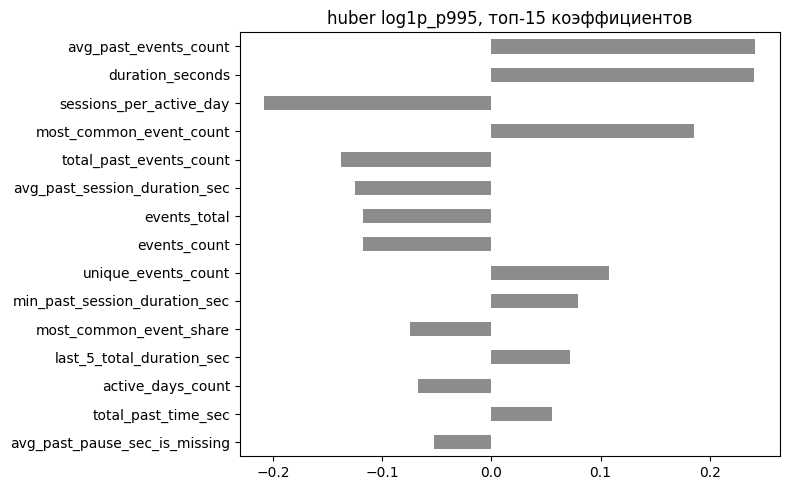

In [9]:
pack = packs[targets[0]]
ncols = [c for c in pack.xtrain.columns if c not in pack.catcols]
sc = StandardScaler().fit(pack.xtrain[ncols])
fwd, inv = makescale(pack.ytrain, "log1p_p995")
hb = HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=300).fit(sc.transform(pack.xtrain[ncols]), fwd(pack.ytrain))
coef = pd.Series(hb.coef_, index=ncols)
coef.reindex(coef.abs().sort_values().tail(15).index).plot.barh(figsize=(8, 5), color="#8c8c8c")
plt.title("huber log1p_p995, топ-15 коэффициентов")
plt.tight_layout()
plt.show()

## Остатки лучшей линейной модели

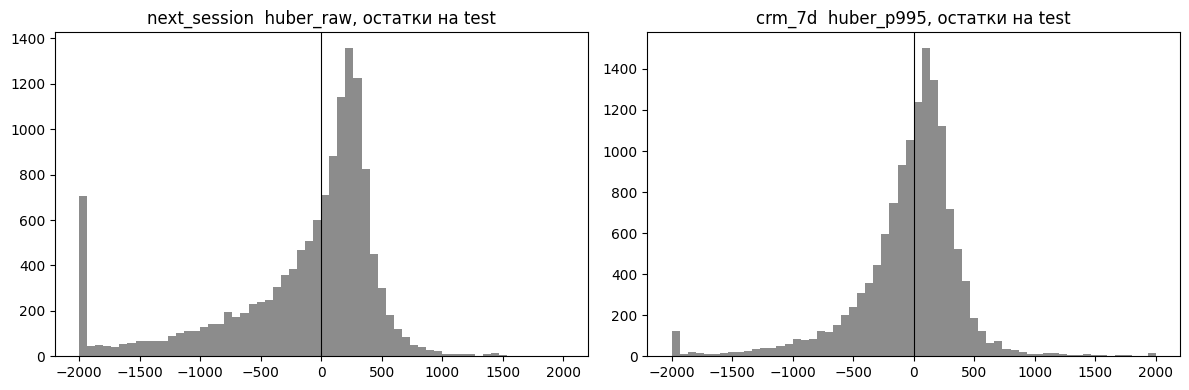

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, t in zip(axes, targets):
    sub = res[(res["target"] == t) & (res["model_family"] == "linear")]
    best = sub.loc[sub["val_mae"].idxmin(), "model_name"]
    yt, yp = preds[(t, best)]
    ax.hist(np.clip(yp - yt, -2000, 2000), bins=60, color="#8c8c8c")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(labels[t] + "  " + best + ", остатки на test")
plt.tight_layout()
plt.show()

In [11]:
pd.DataFrame(rows).to_csv("linres.csv", index=False)
out = {}
for key, val in preds.items():
    out[labels[key[0]] + "|" + key[1]] = np.vstack(val)
np.savez("linpreds.npz", **out)